### Quantium Virtual Internship - Retail Strategy and Analytics

https://www.theforage.com/simulations/quantium/data-analytics-rqkb 

### **Task 1. Understand the situation. Data exploration **

There is a data sets from grocery store provided
 - tranzaction data
 - purchase behaviour 
Client requested to understand customer segments and purchausing potato chips behaviour

Tasks to do:
 - Data exploration
 - Analysing customer behaviour

In [393]:
import pandas as pd               
import numpy as np                
import datetime
from collections import Counter
import re
import matplotlib.pyplot as plt
import plotly.express as px


In [394]:
df_pb = pd.read_csv('QVI_purchase_behaviour.csv')
df_tranz = pd.read_excel('QVI_transaction_data.xlsx')

#### Exploratory data analysis
Examining transaction data

In [395]:
df_tranz.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8


In [396]:
df_tranz.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264836 entries, 0 to 264835
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   DATE            264836 non-null  int64  
 1   STORE_NBR       264836 non-null  int64  
 2   LYLTY_CARD_NBR  264836 non-null  int64  
 3   TXN_ID          264836 non-null  int64  
 4   PROD_NBR        264836 non-null  int64  
 5   PROD_NAME       264836 non-null  object 
 6   PROD_QTY        264836 non-null  int64  
 7   TOT_SALES       264836 non-null  float64
dtypes: float64(1), int64(6), object(1)
memory usage: 16.2+ MB


In [397]:
# convert DATE column to datetime type from intger
origin = pd.Timestamp("30/12/1899")
df_tranz.DATE = df_tranz.DATE.apply(lambda x: origin + pd.Timedelta(days=x))

In [398]:
df_tranz.describe()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES
count,264836,264836.00000,2.648360e+05,2.648360e+05,264836.000000,264836.000000,264836.000000
mean,2018-12-30 00:52:12.879215616,135.08011,1.355495e+05,1.351583e+05,56.583157,1.907309,7.304200
min,2018-07-01 00:00:00,1.00000,1.000000e+03,1.000000e+00,1.000000,1.000000,1.500000
25%,2018-09-30 00:00:00,70.00000,7.002100e+04,6.760150e+04,28.000000,2.000000,5.400000
50%,2018-12-30 00:00:00,130.00000,1.303575e+05,1.351375e+05,56.000000,2.000000,7.400000
75%,2019-03-31 00:00:00,203.00000,2.030942e+05,2.027012e+05,85.000000,2.000000,9.200000
max,2019-06-30 00:00:00,272.00000,2.373711e+06,2.415841e+06,114.000000,200.000000,650.000000
std,NaN,76.78418,8.057998e+04,7.813303e+04,32.826638,0.643654,3.083226


In [400]:
# examine PROD_NAME column

df_tranz.PROD_NAME.unique().size

114

Examine the words in PROD_NAME to see if there are any incorrect entries such as products that are not chips

In [ ]:
# clean product names, remove package weights like "150g" and special symbols
df_tranz['PROD_NAME_CLEAN'] = df_tranz['PROD_NAME'].str.replace(r'\s*\d+\s*[gG]', '', regex=True).str.strip()

df_tranz['PROD_NAME_CLEAN'] = df_tranz['PROD_NAME_CLEAN'].str.replace(r'[^A-Za-zÀ-ÿ\s]', ' ', regex=True).str.replace(r'\s+', ' ', regex=True).str.strip()


In [402]:
df_tranz.PROD_NAME_CLEAN.unique()

array(['Natural Chip Compny SeaSalt', 'CCs Nacho Cheese',
       'Smiths Crinkle Cut Chips Chicken',
       'Smiths Chip Thinly S Cream Onion',
       'Kettle Tortilla ChpsHny Jlpno Chili',
       'Old El Paso Salsa Dip Tomato Mild',
       'Smiths Crinkle Chips Salt Vinegar', 'Grain Waves Sweet Chilli',
       'Doritos Corn Chip Mexican Jalapeno',
       'Grain Waves Sour Cream Chives', 'Kettle Sensations Siracha Lime',
       'Twisties Cheese', 'WW Crinkle Cut Chicken',
       'Thins Chips Light Tangy', 'CCs Original', 'Burger Rings',
       'NCC Sour Cream Garden Chives',
       'Doritos Corn Chip Southern Chicken', 'Cheezels Cheese Box',
       'Smiths Crinkle Original', 'Infzns Crn Crnchers Tangy Gcamole',
       'Kettle Sea Salt And Vinegar', 'Smiths Chip Thinly Cut Original',
       'Kettle Original', 'Red Rock Deli Thai Chilli Lime',
       'Pringles Sthrn FriedChicken', 'Pringles Sweet Spcy BBQ',
       'Red Rock Deli SR Salsa Mzzrlla', 'Thins Chips Originl saltd',
       'Red

In [403]:
# Find and sort most common words

# 1. Convert everything to lowercase and join all text into one string
text = ' '.join(df_tranz['PROD_NAME_CLEAN'].str.lower())

# 2. Split into individual words
words = text.split()

# 3. Count the frequency of each word
word_counts = Counter(words)

# 4. Sort by frequency (highest to lowest)
sorted_counts = word_counts.most_common()

# Display the top words
print(sorted_counts)

[('chips', 49770), ('kettle', 41288), ('smiths', 28860), ('salt', 27976), ('cheese', 27890), ('pringles', 25102), ('doritos', 24962), ('crinkle', 23960), ('corn', 22063), ('original', 21560), ('cut', 20754), ('chip', 18645), ('chicken', 18577), ('salsa', 18094), ('cream', 16926), ('chilli', 15390), ('sea', 14145), ('thins', 14075), ('sour', 13882), ('crisps', 12607), ('vinegar', 12402), ('rrd', 11894), ('sweet', 11060), ('infuzions', 11057), ('supreme', 10963), ('chives', 10951), ('ww', 10320), ('cobs', 9693), ('popd', 9693), ('tortilla', 9580), ('tostitos', 9471), ('twisties', 9454), ('bbq', 9434), ('sensations', 9429), ('lime', 9347), ('old', 9324), ('el', 9324), ('paso', 9324), ('dip', 9324), ('swt', 7987), ('tomato', 7669), ('thinly', 7507), ('tyrrells', 6442), ('and', 6373), ('tangy', 6332), ('sourcream', 6296), ('grain', 6272), ('waves', 6272), ('sr', 6253), ('lightly', 6248), ('salted', 6248), ('soy', 6121), ('onion', 6116), ('natural', 6050), ('mild', 6048), ('red', 5885), ('ro

In [404]:
df_tranz[df_tranz['PROD_NAME_CLEAN'].str.contains('salsa', case=False, na=False)].PROD_NAME_CLEAN.value_counts()

PROD_NAME_CLEAN
Old El Paso Salsa Dip Chnky Tom Ht    3125
Old El Paso Salsa Dip Tomato Med      3114
Old El Paso Salsa Dip Tomato Mild     3085
Woolworths Mild Salsa                 1491
Doritos Salsa Mild                    1472
Smiths Crinkle Cut Tomato Salsa       1470
Red Rock Deli SR Salsa Mzzrlla        1458
Doritos Salsa Medium                  1449
Woolworths Medium Salsa               1430
Name: count, dtype: int64

In [405]:
# remove all products contains 'salsa' word
df_tranz = df_tranz[~df_tranz['PROD_NAME_CLEAN'].str.contains('salsa', case=False, na=False)]
df_tranz.PROD_NAME_CLEAN.nunique()

105

In [406]:
df_tranz.info()

<class 'pandas.core.frame.DataFrame'>
Index: 246742 entries, 0 to 264835
Data columns (total 9 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   DATE             246742 non-null  datetime64[ns]
 1   STORE_NBR        246742 non-null  int64         
 2   LYLTY_CARD_NBR   246742 non-null  int64         
 3   TXN_ID           246742 non-null  int64         
 4   PROD_NBR         246742 non-null  int64         
 5   PROD_NAME        246742 non-null  object        
 6   PROD_QTY         246742 non-null  int64         
 7   TOT_SALES        246742 non-null  float64       
 8   PROD_NAME_CLEAN  246742 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(5), object(2)
memory usage: 18.8+ MB


In [407]:
df_tranz.describe()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES
count,246742,246742.000000,2.467420e+05,2.467420e+05,246742.000000,246742.000000,246742.000000
mean,2018-12-30 01:19:01.211467520,135.051098,1.355310e+05,1.351311e+05,56.351789,1.908062,7.321322
min,2018-07-01 00:00:00,1.000000,1.000000e+03,1.000000e+00,1.000000,1.000000,1.700000
25%,2018-09-30 00:00:00,70.000000,7.001500e+04,6.756925e+04,26.000000,2.000000,5.800000
50%,2018-12-30 00:00:00,130.000000,1.303670e+05,1.351830e+05,53.000000,2.000000,7.400000
75%,2019-03-31 00:00:00,203.000000,2.030840e+05,2.026538e+05,87.000000,2.000000,8.800000
max,2019-06-30 00:00:00,272.000000,2.373711e+06,2.415841e+06,114.000000,200.000000,650.000000
std,NaN,76.787096,8.071528e+04,7.814772e+04,33.695428,0.659831,3.077828


Notes:
1) PROD_QTY has possible outliers - case where 200 packets of chips are bought in one transaction. Need to investigate.

In [408]:
print(df_tranz.PROD_QTY.value_counts())
df_tranz[df_tranz['PROD_QTY']==200]

PROD_QTY
2      220070
1       25476
5         415
3         408
4         371
200         2
Name: count, dtype: int64


,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PROD_NAME_CLEAN
69762,2018-08-19,226,226000,226201,4,Dorito Corn Chp Supreme 380g,200,650.0,Dorito Corn Chp Supreme
69763,2019-05-20,226,226000,226210,4,Dorito Corn Chp Supreme 380g,200,650.0,Dorito Corn Chp Supreme


There are two transactions where 200 packets of chips are bought in one transaction and both of these transactions were by the same customer. 
Let's see if the customer has had other transactions

In [409]:
df_tranz[df_tranz['LYLTY_CARD_NBR']==226000]

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PROD_NAME_CLEAN
69762,2018-08-19,226,226000,226201,4,Dorito Corn Chp Supreme 380g,200,650.0,Dorito Corn Chp Supreme
69763,2019-05-20,226,226000,226210,4,Dorito Corn Chp Supreme 380g,200,650.0,Dorito Corn Chp Supreme


In [410]:
df_pb[df_pb['LYLTY_CARD_NBR']==226000]

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
59694,226000,OLDER FAMILIES,Premium


Conclusion: looks like it is extraordinary customer, who made just two transactions.
Decided to remove this LYLTY_CARD_NBR

In [411]:
df_tranz = df_tranz[~(df_tranz['LYLTY_CARD_NBR']==226000)]
df_tranz.describe()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES
count,246740,246740.000000,2.467400e+05,2.467400e+05,246740.000000,246740.000000,246740.000000
mean,2018-12-30 01:18:58.448569344,135.050361,1.355303e+05,1.351304e+05,56.352213,1.906456,7.316113
min,2018-07-01 00:00:00,1.000000,1.000000e+03,1.000000e+00,1.000000,1.000000,1.700000
25%,2018-09-30 00:00:00,70.000000,7.001500e+04,6.756875e+04,26.000000,2.000000,5.800000
50%,2018-12-30 00:00:00,130.000000,1.303670e+05,1.351815e+05,53.000000,2.000000,7.400000
75%,2019-03-31 00:00:00,203.000000,2.030832e+05,2.026522e+05,87.000000,2.000000,8.800000
max,2019-06-30 00:00:00,272.000000,2.373711e+06,2.415841e+06,114.000000,5.000000,29.500000
std,NaN,76.786971,8.071520e+04,7.814760e+04,33.695235,0.342499,2.474897


Let's look at the number of transaction lines over time to see if there are any obvious data issues such as missing data.

In [412]:
# Count number of transactions per day
df_tranz.groupby('DATE').size()

DATE
2018-07-01    663
2018-07-02    650
2018-07-03    674
2018-07-04    669
2018-07-05    660
             ... 
2019-06-26    657
2019-06-27    669
2019-06-28    673
2019-06-29    703
2019-06-30    704
Length: 364, dtype: int64

In [413]:
# 1. Create a complete sequence of dates
date_range = pd.date_range(start='2018-07-01', end='2019-06-30', freq='D')

# 2. Count number of transactions per day
daily_counts = df_tranz.groupby('DATE').size()

# Convert to DataFrame
daily_counts = daily_counts.reindex(date_range, fill_value=0)
daily_counts.index.name = 'DATE'
daily_counts = daily_counts.rename('transactions').reset_index()

# 3. Find missing dates (where count is 0)
missing_dates = daily_counts[daily_counts['transactions'] == 0]

print("Missing dates:")
print(missing_dates)



Missing dates:
          DATE  transactions
177 2018-12-25             0


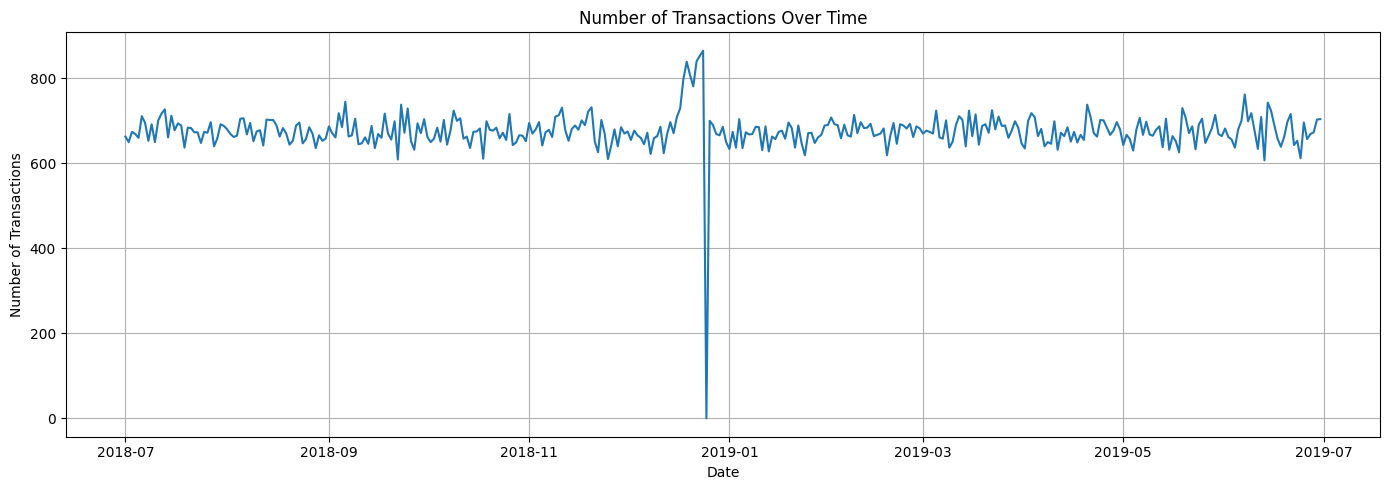

In [414]:
# 4. Plot number of transactions over time
plt.figure(figsize=(14,5))
plt.plot(daily_counts['DATE'], daily_counts['transactions'])
plt.title('Number of Transactions Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Transactions')
plt.grid(True)
plt.tight_layout()
plt.show()

conclusion: * There is an increase in purchases in December and a break on 25th of Dec. It happened because shops were closed on Christmas holiday.
* there are no other outliers were found.

In [415]:
# Add column PACKAGE_SIZE
df_tranz['PACK_SIZE'] = df_tranz['PROD_NAME'].str.extract(r'(\d+)\s*[gG]').astype(float)


In [416]:
df_tranz.describe()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES,PACK_SIZE
count,246740,246740.000000,2.467400e+05,2.467400e+05,246740.000000,246740.000000,246740.000000,246740.000000
mean,2018-12-30 01:18:58.448569344,135.050361,1.355303e+05,1.351304e+05,56.352213,1.906456,7.316113,175.583521
min,2018-07-01 00:00:00,1.000000,1.000000e+03,1.000000e+00,1.000000,1.000000,1.700000,70.000000
25%,2018-09-30 00:00:00,70.000000,7.001500e+04,6.756875e+04,26.000000,2.000000,5.800000,150.000000
50%,2018-12-30 00:00:00,130.000000,1.303670e+05,1.351815e+05,53.000000,2.000000,7.400000,170.000000
75%,2019-03-31 00:00:00,203.000000,2.030832e+05,2.026522e+05,87.000000,2.000000,8.800000,175.000000
max,2019-06-30 00:00:00,272.000000,2.373711e+06,2.415841e+06,114.000000,5.000000,29.500000,380.000000
std,NaN,76.786971,8.071520e+04,7.814760e+04,33.695235,0.342499,2.474897,59.432118


PACK_SIZE
70.0      1507
90.0      3008
110.0    22387
125.0     1454
134.0    25102
135.0     3257
150.0    40203
160.0     2970
165.0    15297
170.0    19983
175.0    66390
180.0     1468
190.0     2995
200.0     4473
210.0     6272
220.0     1564
250.0     3169
270.0     6285
330.0    12540
380.0     6416
Name: count, dtype: int64


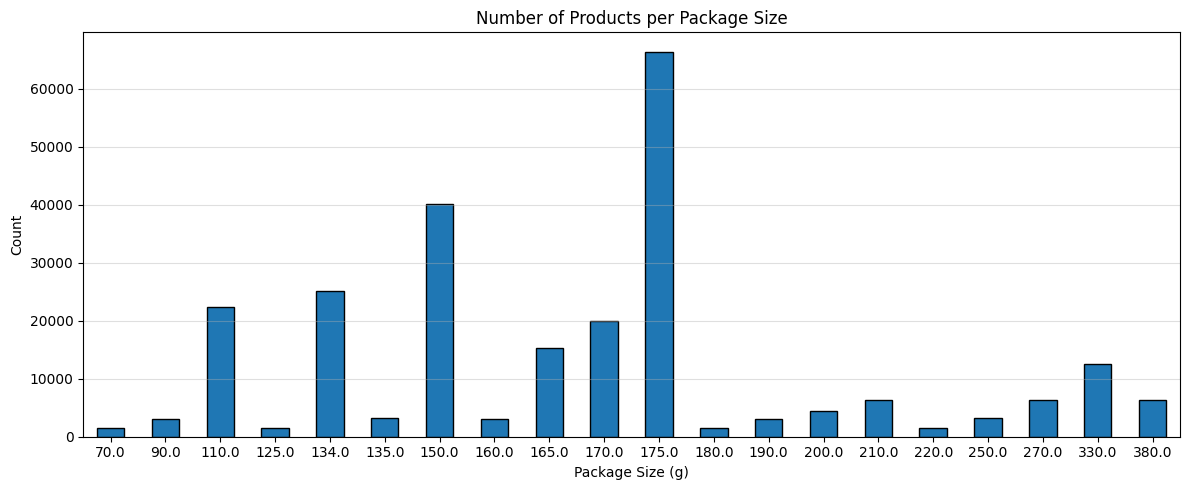

In [417]:
# Count how many products per package size
pack_counts = df_tranz['PACK_SIZE'].value_counts().sort_index()
print(pack_counts)

# Plot bar chart
plt.figure(figsize=(12,5))
pack_counts.plot(kind='bar', edgecolor='black')
plt.title('Number of Products per Package Size')
plt.xlabel('Package Size (g)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

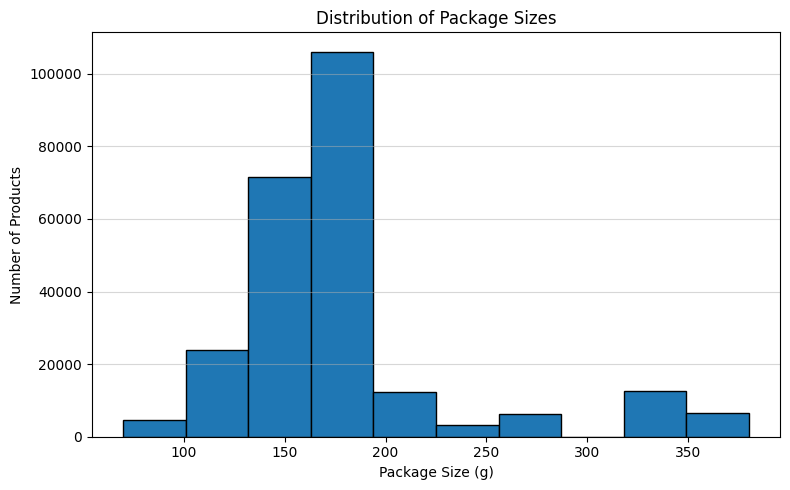

In [418]:
# plot Histogram for PACK_SIZE

plt.figure(figsize=(8,5))
plt.hist(df_tranz['PACK_SIZE'], bins=10, edgecolor='black')
plt.title('Distribution of Package Sizes')
plt.xlabel('Package Size (g)')
plt.ylabel('Number of Products')
plt.grid(axis='y', alpha=0.5)
plt.tight_layout()
plt.show()

In [419]:
## one more way to built Histogram
#df_tranz['PACK_SIZE'].plot(kind='hist', bins=10, figsize=(8,5), edgecolor='black', title='Distribution of Package Sizes')
#plt.xlabel('Package Size (g)')
#plt.ylabel('Number of Products')
#plt.grid(axis='y', alpha=0.5)
#plt.show()

In [420]:
# Add column BRAND
df_tranz['BRAND'] = df_tranz['PROD_NAME'].str.split().str[0]
df_tranz['BRAND'].value_counts().sort_index()

BRAND
Burger         1564
CCs            4551
Cheetos        2927
Cheezels       4603
Cobs           9693
Dorito         3183
Doritos       22041
French         1418
Grain          6272
GrnWves        1468
Infuzions     11057
Infzns         3144
Kettle        41288
NCC            1419
Natural        6050
Pringles      25102
RRD           11894
Red            4427
Smith          2963
Smiths        27390
Snbts          1576
Sunbites       1432
Thins         14075
Tostitos       9471
Twisties       9454
Tyrrells       6442
WW            10320
Woolworths     1516
Name: count, dtype: int64

In [421]:
df_tranz_copy = df_tranz.copy()
#df_tranz_copy

In [422]:
df_tranz[df_tranz['PROD_NAME'].str.startswith('Cheezels')]

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PROD_NAME_CLEAN,PACK_SIZE,BRAND
19,2019-05-16,23,23067,19162,56,Cheezels Cheese Box 125g,1,2.1,Cheezels Cheese Box,125.0,Cheezels
128,2019-05-20,172,172068,173166,23,Cheezels Cheese 330g,2,11.4,Cheezels Cheese,330.0,Cheezels
218,2019-03-11,1,1475,557,23,Cheezels Cheese 330g,1,5.7,Cheezels Cheese,330.0,Cheezels
226,2019-01-09,2,2386,996,56,Cheezels Cheese Box 125g,1,2.1,Cheezels Cheese Box,125.0,Cheezels
235,2018-10-09,3,3164,1778,23,Cheezels Cheese 330g,2,11.4,Cheezels Cheese,330.0,Cheezels
...,...,...,...,...,...,...,...,...,...,...,...
264724,2019-05-30,266,266381,264220,56,Cheezels Cheese Box 125g,1,2.1,Cheezels Cheese Box,125.0,Cheezels
264756,2019-04-28,268,268491,264947,56,Cheezels Cheese Box 125g,1,2.1,Cheezels Cheese Box,125.0,Cheezels
264762,2018-08-08,269,269133,265833,56,Cheezels Cheese Box 125g,2,4.2,Cheezels Cheese Box,125.0,Cheezels
264766,2019-05-23,269,269133,265838,56,Cheezels Cheese Box 125g,2,4.2,Cheezels Cheese Box,125.0,Cheezels


In [423]:
# BRAND name adjustments
df_tranz['BRAND'] = df_tranz['BRAND'].replace('Smith', 'Smiths')
df_tranz['BRAND'] = df_tranz['BRAND'].replace('Burger', 'Smiths')

df_tranz['BRAND'] = df_tranz['BRAND'].replace('Snbts', 'Sunbites')

df_tranz['BRAND'] = df_tranz['BRAND'].replace('Infzns', 'Infuzions')

df_tranz['BRAND'] = df_tranz['BRAND'].replace('Red', 'RRD')

df_tranz['BRAND'] = df_tranz['BRAND'].replace('Dorito', 'Doritos')

df_tranz['BRAND'] = df_tranz['BRAND'].replace('Grain', 'Grain Waves')
df_tranz['BRAND'] = df_tranz['BRAND'].replace('GrnWves', 'Grain Waves')

df_tranz['BRAND'] = df_tranz['BRAND'].replace('French', 'French Fries')

df_tranz['BRAND'] = df_tranz['BRAND'].replace('Natural', 'NCC')
df_tranz['BRAND'].value_counts().sort_index()

BRAND
CCs              4551
Cheetos          2927
Cheezels         4603
Cobs             9693
Doritos         25224
French Fries     1418
Grain Waves      7740
Infuzions       14201
Kettle          41288
NCC              7469
Pringles        25102
RRD             16321
Smiths          31917
Sunbites         3008
Thins           14075
Tostitos         9471
Twisties         9454
Tyrrells         6442
WW              10320
Woolworths       1516
Name: count, dtype: int64

### Examining customer data

In [424]:
df_pb.head(4)

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream


In [425]:
df_pb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72637 entries, 0 to 72636
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   LYLTY_CARD_NBR    72637 non-null  int64 
 1   LIFESTAGE         72637 non-null  object
 2   PREMIUM_CUSTOMER  72637 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [426]:
df_pb.LIFESTAGE.value_counts()

LIFESTAGE
RETIREES                  14805
OLDER SINGLES/COUPLES     14609
YOUNG SINGLES/COUPLES     14441
OLDER FAMILIES             9780
YOUNG FAMILIES             9178
MIDAGE SINGLES/COUPLES     7275
NEW FAMILIES               2549
Name: count, dtype: int64

In [427]:
df_pb.PREMIUM_CUSTOMER.value_counts()

PREMIUM_CUSTOMER
Mainstream    29245
Budget        24470
Premium       18922
Name: count, dtype: int64

In [428]:
df_pb.sort_values(by = 'LIFESTAGE')

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
55568,209193,MIDAGE SINGLES/COUPLES,Budget
70886,266006,MIDAGE SINGLES/COUPLES,Premium
19871,72304,MIDAGE SINGLES/COUPLES,Mainstream
19870,72303,MIDAGE SINGLES/COUPLES,Mainstream
61011,230164,MIDAGE SINGLES/COUPLES,Premium
...,...,...,...
39612,148345,YOUNG SINGLES/COUPLES,Budget
39611,148344,YOUNG SINGLES/COUPLES,Mainstream
39599,148332,YOUNG SINGLES/COUPLES,Mainstream
39650,148383,YOUNG SINGLES/COUPLES,Mainstream


#### Merge transaction data to customer data 

In [429]:
print(df_pb.LYLTY_CARD_NBR.nunique())
print(df_tranz.LYLTY_CARD_NBR.nunique())

72637
71287


In [430]:
df_merged = df_tranz.merge(df_pb, on='LYLTY_CARD_NBR', how='left')

In [431]:
print("Size df_tranz:", df_tranz.shape)
print("Size df_merged:", df_merged.shape)

Size df_tranz: (246740, 11)
Size df_merged: (246740, 13)


In [432]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246740 entries, 0 to 246739
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   DATE              246740 non-null  datetime64[ns]
 1   STORE_NBR         246740 non-null  int64         
 2   LYLTY_CARD_NBR    246740 non-null  int64         
 3   TXN_ID            246740 non-null  int64         
 4   PROD_NBR          246740 non-null  int64         
 5   PROD_NAME         246740 non-null  object        
 6   PROD_QTY          246740 non-null  int64         
 7   TOT_SALES         246740 non-null  float64       
 8   PROD_NAME_CLEAN   246740 non-null  object        
 9   PACK_SIZE         246740 non-null  float64       
 10  BRAND             246740 non-null  object        
 11  LIFESTAGE         246740 non-null  object        
 12  PREMIUM_CUSTOMER  246740 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(5), object(5)
memor

conclusion: there are no nulls! So all our customers in the transaction data has been accounted for in the customer dataset.

#### Data analysis on customer segments 

Defining some metrics of interest to the client to understand customer segments behaviour:
- Who spends the most on chips (total sales), describing customers by lifestage and how premium their general purchasing behaviour is
- How many customers are in each segment
- How many chips are bought per customer by segment
- What's the average chip price by customer segment 
- The customer's total spend over the period and total spend for each transaction to understand what proportion of their grocery spend is on chips 
- Proportion of customers in each customer segment overall to compare against the mix of customers who purchase chips

In [433]:
df_merged.columns

Index(['DATE', 'STORE_NBR', 'LYLTY_CARD_NBR', 'TXN_ID', 'PROD_NBR',
       'PROD_NAME', 'PROD_QTY', 'TOT_SALES', 'PROD_NAME_CLEAN', 'PACK_SIZE',
       'BRAND', 'LIFESTAGE', 'PREMIUM_CUSTOMER'],
      dtype='object')

#### Metric #1 Who spends the most on chips (total sales), by LIFESTAGE and by PREMIUM_CUSTOMER 

In [434]:
# 1. Aggregate: total sales by LIFESTAGE x PREMIUM_CUSTOMER
sales = df_merged.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'], as_index=False)['TOT_SALES'].sum()

# 2. Calc total sales
total = sales['TOT_SALES'].sum()

# 3 Add Percentage column
sales['PERCENT_SALES'] = sales['TOT_SALES'] / total * 100
print(sales)


                 LIFESTAGE PREMIUM_CUSTOMER  TOT_SALES  PERCENT_SALES
0   MIDAGE SINGLES/COUPLES           Budget   33345.70       1.847225
1   MIDAGE SINGLES/COUPLES       Mainstream   84734.25       4.693956
2   MIDAGE SINGLES/COUPLES          Premium   54443.85       3.015983
3             NEW FAMILIES           Budget   20607.45       1.141575
4             NEW FAMILIES       Mainstream   15979.70       0.885215
5             NEW FAMILIES          Premium   10760.80       0.596108
6           OLDER FAMILIES           Budget  156863.75       8.689657
7           OLDER FAMILIES       Mainstream   96413.55       5.340945
8           OLDER FAMILIES          Premium   75242.60       4.168155
9    OLDER SINGLES/COUPLES           Budget  127833.60       7.081497
10   OLDER SINGLES/COUPLES       Mainstream  124648.50       6.905054
11   OLDER SINGLES/COUPLES          Premium  123537.55       6.843512
12                RETIREES           Budget  105916.30       5.867361
13                RE

In [435]:
# fig = px.treemap(sales, path=['LIFESTAGE', 'PREMIUM_CUSTOMER'], values='PERCENT_SALES',
#                  title='Proportion of sales')
# fig.show()

In [ ]:
# 1) Choose one color per PREMIUM_CUSTOMER 
color_map = {
    'Premium': '#4e79a7',
    'Mainstream': '#f28e2b', 
    'Budget':  '#59a14f',
}

# 2) Build treemap
fig = px.treemap(
    sales,
    path=['LIFESTAGE', 'PREMIUM_CUSTOMER'],   # hierarchy
    values='PERCENT_SALES',
    color='PREMIUM_CUSTOMER',                        
    color_discrete_map=color_map,
    custom_data=['TOT_SALES', 'PERCENT_SALES']  # pass extra fields for hover/text
)

# 3) Labels and hover tiles 
fig.update_traces(
    texttemplate='%{label}<br>%{percentRoot:.1%}',  # e.g. "Premium\n12.3%"
    hovertemplate=(
        '<b>%{label}</b><br>'
        'Lifestage: %{id}<br>'
        'Total sales: %{customdata[0]:,.0f}<br>'
        'Share of total: %{customdata[1]:.2f}%'
        '<extra></extra>'
    ),
    tiling=dict(pad=2),  # a touch more spacing
)

fig.update_layout(
    title='Proportion of Sales by Lifestage and Premium Customer',
    margin=dict(l=10, r=10, t=40, b=10),
    plot_bgcolor='#f5f5f5',
)

fig.show()

Conclusion:
- The largest sales segemnts are Budget - older families, Mainstream - young singles/couples, and Mainstream - Retirees

#### Mectric #2 Number of customers by LIFESTAGE and PREMIUM_CUSTOMER

In [437]:
# 1. Aggregate: total sales by LIFESTAGE x PREMIUM_CUSTOMER
cust_nmb = (
    df_merged
    .groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'], as_index=False)
    .agg(CUSTM_NMB=('LYLTY_CARD_NBR', 'nunique'))
)

print(cust_nmb)

                 LIFESTAGE PREMIUM_CUSTOMER  CUSTM_NMB
0   MIDAGE SINGLES/COUPLES           Budget       1474
1   MIDAGE SINGLES/COUPLES       Mainstream       3298
2   MIDAGE SINGLES/COUPLES          Premium       2369
3             NEW FAMILIES           Budget       1087
4             NEW FAMILIES       Mainstream        830
5             NEW FAMILIES          Premium        575
6           OLDER FAMILIES           Budget       4611
7           OLDER FAMILIES       Mainstream       2788
8           OLDER FAMILIES          Premium       2231
9    OLDER SINGLES/COUPLES           Budget       4849
10   OLDER SINGLES/COUPLES       Mainstream       4858
11   OLDER SINGLES/COUPLES          Premium       4682
12                RETIREES           Budget       4385
13                RETIREES       Mainstream       6358
14                RETIREES          Premium       3812
15          YOUNG FAMILIES           Budget       3953
16          YOUNG FAMILIES       Mainstream       2685
17        

In [438]:
# plot bar graph
fig = px.bar(
    cust_nmb,
    x='LIFESTAGE',
    y='CUSTM_NMB',
    color='PREMIUM_CUSTOMER',
    color_discrete_map=color_map,
    barmode='group',   # groups bars by PREMIUM_CUSTOMER within each LIFESTAGE
    text='CUSTM_NMB',  # show counts on top of bars
    title='Number of Unique Customers by Lifestage and Premium Customer'
)

# styling
fig.update_traces(textposition='outside')

fig.show()

Conclusion:
- Mainstream Young Singles/Couples and Mainstream Retirees are the largest customer groups who are buying chips.
- Budget Older Families buy much less chips.

#### Metric #3 Average number of units per customer by LIFESTAGE and PREMIUM_CUSTOMER

In [439]:
df_merged.columns

Index(['DATE', 'STORE_NBR', 'LYLTY_CARD_NBR', 'TXN_ID', 'PROD_NBR',
       'PROD_NAME', 'PROD_QTY', 'TOT_SALES', 'PROD_NAME_CLEAN', 'PACK_SIZE',
       'BRAND', 'LIFESTAGE', 'PREMIUM_CUSTOMER'],
      dtype='object')

In [440]:
# 1. Aggregate: sum of unit and customer nmb by LIFESTAGE x PREMIUM_CUSTOMER
avg_units = (
    df_merged
    .groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'], as_index=False)
    .agg(
        TOTAL_UNITS=('PROD_QTY', 'sum'),
        UNIQUE_CUSTOMERS=('LYLTY_CARD_NBR', 'nunique')
    )
)

avg_units['AVG'] = avg_units['TOTAL_UNITS'] / avg_units['UNIQUE_CUSTOMERS']

print(avg_units)

                 LIFESTAGE PREMIUM_CUSTOMER  TOTAL_UNITS  UNIQUE_CUSTOMERS  \
0   MIDAGE SINGLES/COUPLES           Budget         8883              1474   
1   MIDAGE SINGLES/COUPLES       Mainstream        21213              3298   
2   MIDAGE SINGLES/COUPLES          Premium        14400              2369   
3             NEW FAMILIES           Budget         5241              1087   
4             NEW FAMILIES       Mainstream         4060               830   
5             NEW FAMILIES          Premium         2769               575   
6           OLDER FAMILIES           Budget        41853              4611   
7           OLDER FAMILIES       Mainstream        25804              2788   
8           OLDER FAMILIES          Premium        20239              2231   
9    OLDER SINGLES/COUPLES           Budget        32883              4849   
10   OLDER SINGLES/COUPLES       Mainstream        32607              4858   
11   OLDER SINGLES/COUPLES          Premium        31695        

In [441]:
# plot bar graph
fig = px.bar(
    avg_units,
    x='LIFESTAGE',
    y='AVG',
    color='PREMIUM_CUSTOMER',
    color_discrete_map=color_map,
    barmode='group',   # groups bars by PREMIUM_CUSTOMER within each LIFESTAGE
    title='Units per Customer'
)

# styling
fig.update_traces(textposition='outside')

fig.show()

Conclusion:
- Older families and Young families buy more chips in general.
- Premium level does not depends a lot from Lifestage segment. Amount of chips that each Lifestage customer segment buy is almost the same. 

#### Metric #4 Average price per unit by LIFESTAGE and PREMIUM_CUSTOMER

In [442]:
# 1. Aggregate: sum of unit and customer nmb by LIFESTAGE x PREMIUM_CUSTOMER
avg_price = (
    df_merged
    .groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'], as_index=False)
    .agg(
        TOTAL_UNITS=('PROD_QTY', 'sum'),
        TOTAL_PRICE=('TOT_SALES', 'sum')
    )
)

avg_price['AVG_PRICE'] = avg_price['TOTAL_PRICE'] / avg_price['TOTAL_UNITS']

print(avg_price)

                 LIFESTAGE PREMIUM_CUSTOMER  TOTAL_UNITS  TOTAL_PRICE  \
0   MIDAGE SINGLES/COUPLES           Budget         8883     33345.70   
1   MIDAGE SINGLES/COUPLES       Mainstream        21213     84734.25   
2   MIDAGE SINGLES/COUPLES          Premium        14400     54443.85   
3             NEW FAMILIES           Budget         5241     20607.45   
4             NEW FAMILIES       Mainstream         4060     15979.70   
5             NEW FAMILIES          Premium         2769     10760.80   
6           OLDER FAMILIES           Budget        41853    156863.75   
7           OLDER FAMILIES       Mainstream        25804     96413.55   
8           OLDER FAMILIES          Premium        20239     75242.60   
9    OLDER SINGLES/COUPLES           Budget        32883    127833.60   
10   OLDER SINGLES/COUPLES       Mainstream        32607    124648.50   
11   OLDER SINGLES/COUPLES          Premium        31695    123537.55   
12                RETIREES           Budget        

In [443]:
# plot bar graph
fig = px.bar(
    avg_price,
    x='LIFESTAGE',
    y='AVG_PRICE',
    color='PREMIUM_CUSTOMER',
    color_discrete_map=color_map,
    barmode='group',   # groups bars by PREMIUM_CUSTOMER within each LIFESTAGE
    title='Average price per unit'
)

# styling
fig.update_traces(textposition='outside')

fig.show()

Conclusion:
- Mainstream midage and young singles and couples appear more willing to pay a slightly higher price per packet of chips compared to their Budget and Premium counterparts.
A likely reason is that Premium customers may prefer healthier snack options and buy chips mainly for occasional or social occasions, rather than regular personal consumption.
This aligns with the lower number of Premium buyers in these segments compared to Mainstream customers.
- The difference in average price per unit isn’t large. 